In [13]:
# Employee attrition is a major challenge for organizations. 
# High attrition leads to increased hiring costs and loss of experienced employees.

# In this project, I analyzed employee data to identify the key factors that contribute to employee attrition and provide
# insights that can help organizations improve retention.

# The goal of this project is to:
 # • Analyze employee data
 # • Identify patterns related to attrition
 # • Understand key factors like satisfaction, salary, and promotion
 # • Provide actionable insights

In [14]:
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Style for better visuals
sns.set(style="whitegrid")

In [2]:
# 2. LOAD DATA
# =========================
df = pd.read_csv("data/employee_chart.csv")

print("First 5 rows:")
print(df.head())


First 5 rows:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  \
0                   3              0     1                      0   
1                   6              0     1                      0   
2                   4              0     1                      0   
3                   5              0     1                      0   
4                   3              0     1                      0   

  Departments   salary  
0        sales     low  
1        sales  medium  
2        sales 

In [3]:
# 3. BASIC INFO (PANDAS)
# =========================
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Departments            14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None

Statistical Summary:
       satisfaction_level  last_evaluation  number_project  \
count        14999.000000     14999.000000    14999.000000   
mean             0.612834         0.716

In [4]:
# 4. DATA CLEANING
# =========================
# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Departments              0
salary                   0
dtype: int64


In [5]:
# 5. NUMPY USAGE (SKILL SHOW)
# =========================
# Example: Calculate average satisfaction level using numpy
avg_satisfaction = np.mean(df['satisfaction_level'])
print("\nAverage Satisfaction Level:", avg_satisfaction)


Average Satisfaction Level: 0.6128335222348156


In [6]:
# 6. FEATURE ANALYSIS
# =========================
print("\nAttrition Count:")
print(df['left'].value_counts())

print("\nDepartments:")
print(df['Departments'].value_counts())


Attrition Count:
left
0    11428
1     3571
Name: count, dtype: int64

Departments:
Departments
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64


In [7]:
# 7. CREATE OUTPUT FOLDER
# =========================
os.makedirs("output", exist_ok=True)

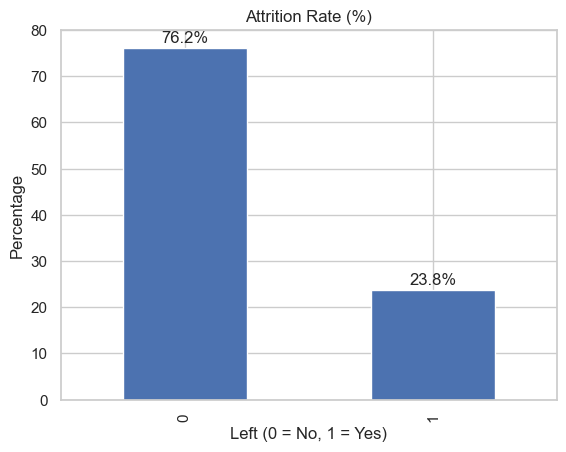

In [8]:
# 8. VISUALIZATION (MATPLOTLIB)
# =========================
attrition_rate = df['left'].value_counts(normalize=True) * 100

plt.figure()
attrition_rate.plot(kind='bar')
plt.title("Attrition Rate (%)")
plt.xlabel("Left (0 = No, 1 = Yes)")
plt.ylabel("Percentage")

# Add labels
for i, v in enumerate(attrition_rate):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.savefig("output/attrition_rate.png")
plt.show()


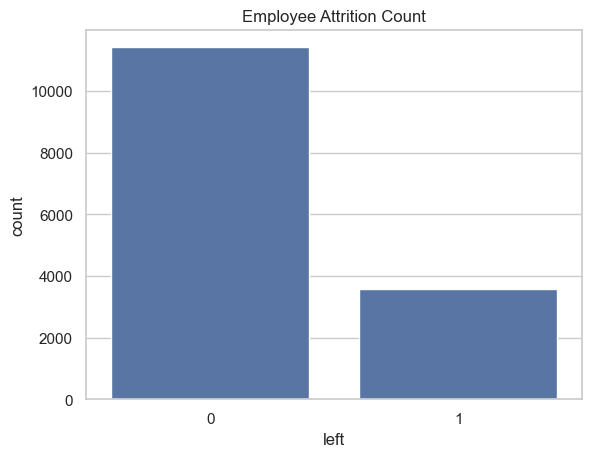

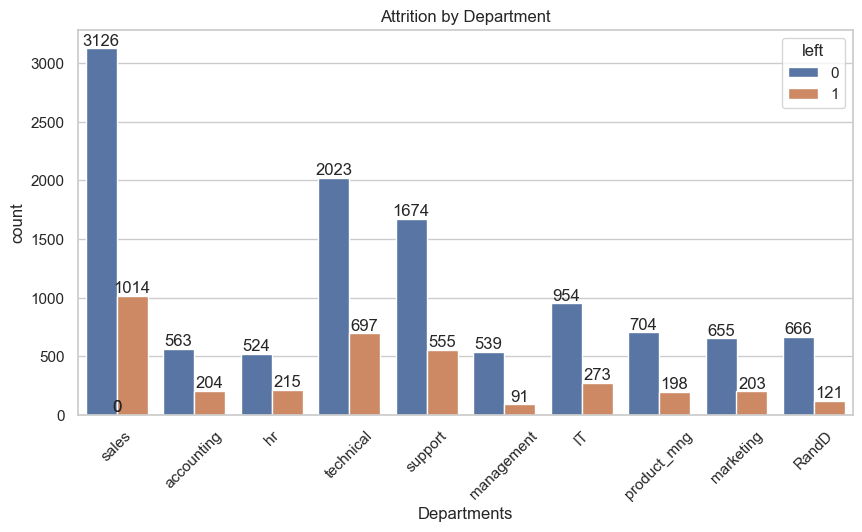

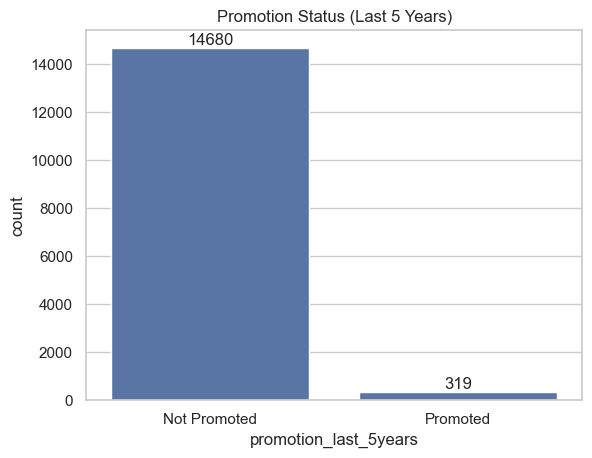

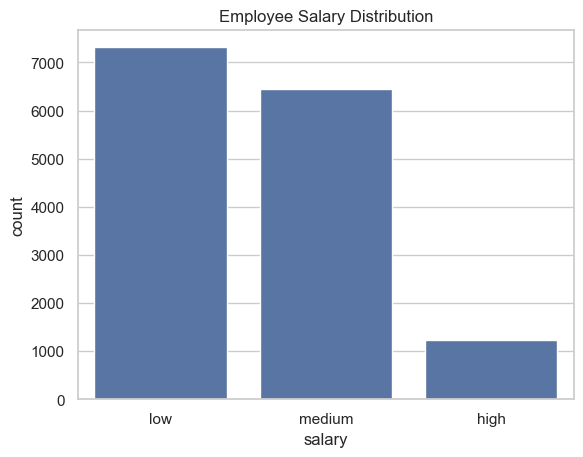

In [9]:
# 9. SEABORN VISUALS
# =========================

# Attrition count
plt.figure()
sns.countplot(x='left', data=df)
plt.title("Employee Attrition Count")
plt.savefig("output/attrition_count.png")
plt.show()

# Department vs Attrition
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x='Departments', hue='left')
plt.xticks(rotation=45)
plt.title("Attrition by Department")

# Add labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.savefig("output/department_attrition.png")
plt.show()

# Promotion analysis
plt.figure()
ax = sns.countplot(x='promotion_last_5years', data=df)
plt.title("Promotion Status (Last 5 Years)")
plt.xticks([0,1], ['Not Promoted', 'Promoted'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.savefig("output/promotion.png")
plt.show()

# Salary distribution
plt.figure()
sns.countplot(data=df, x='salary')
plt.title("Employee Salary Distribution")
plt.savefig("output/salary.png")
plt.show()


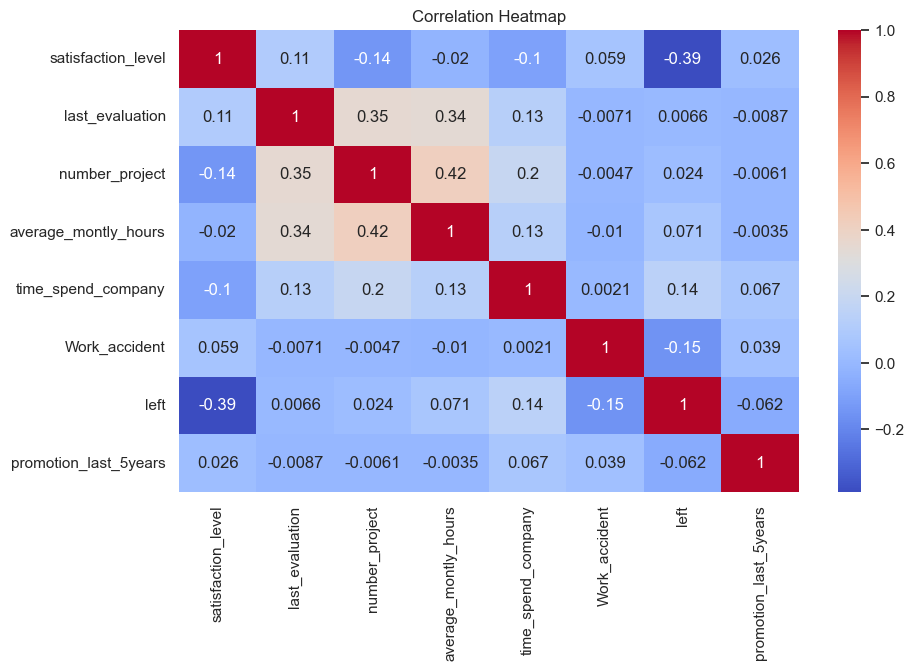

In [10]:
# 10. CORRELATION HEATMAP
# =========================
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("output/correlation.png")
plt.show()

In [11]:
# 11. INSIGHTS (PRINT)
# =========================

print(f"Average Satisfaction Level: {avg_satisfaction:.2f}")
print(f"Attrition Rate: {attrition_rate[1]:.2f}%")

Average Satisfaction Level: 0.61
Attrition Rate: 23.81%


In [12]:
print("\n===== FINAL INSIGHTS =====")

# Insight 1
low_satisfaction = df[df['satisfaction_level'] < 0.5]['left'].mean()
print(f"Employees with low satisfaction are more likely to leave: {low_satisfaction:.2f}")

# Insight 2
high_salary_attrition = df[df['salary'] == 'high']['left'].mean()
low_salary_attrition = df[df['salary'] == 'low']['left'].mean()
print(f"Attrition (Low Salary): {low_salary_attrition:.2f}")
print(f"Attrition (High Salary): {high_salary_attrition:.2f}")

# Insight 3
promotion_attrition = df.groupby('promotion_last_5years')['left'].mean()
print("\nAttrition based on Promotion:")
print(promotion_attrition)

# Insight 4
dept_attrition = df.groupby('Departments')['left'].mean().sort_values(ascending=False)
print("\nTop Departments with High Attrition:")
print(dept_attrition.head())


===== FINAL INSIGHTS =====
Employees with low satisfaction are more likely to leave: 0.56
Attrition (Low Salary): 0.30
Attrition (High Salary): 0.07

Attrition based on Promotion:
promotion_last_5years
0    0.241962
1    0.059561
Name: left, dtype: float64

Top Departments with High Attrition:
Departments
hr            0.290934
accounting    0.265971
technical     0.256250
support       0.248991
sales         0.244928
Name: left, dtype: float64


In [ ]:
# Key Insights:
"""• Employees with low satisfaction levels have significantly higher attrition
   • Employees with low salaries leave more frequently than high salary employees
   • Lack of promotion in last 5 years increases attrition
   • Some departments have consistently higher attrition rates
   """